# 08 · Predicting outcomes from prior history

Research question: can information available before a fight add predictive value? This is sequential historical replay, not a betting system. A/B assignment is a deterministic outcome-independent hash of fight ID.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare chronological features

Each fighter history excludes the entire current date. No lifetime profile performance metrics or current-bout statistics enter the allowlist.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Features and time splits

Train through 2019; validation 2020–2022 selects the model by log loss; test begins in 2023. Later test bouts may use earlier test results in history, as would be known at their dates. Model parameters stay fixed.

In [3]:
from src.modeling import model_frame, train_models, FEATURES
model_data = model_frame(data['fights'])
print('Allowed features:', FEATURES)
display(model_data.groupby('split',sort=False).agg(fights=('fight_id','size'), first_date=('event_date','min'), last_date=('event_date','max')))
display(model_data[FEATURES].isna().mean().rename('Missing share'))

Allowed features: ['age_diff', 'prior_ufc_fights_diff', 'prior_wins_diff', 'prior_losses_diff', 'prior_win_rate_diff', 'prior_ko_rate_diff', 'prior_submission_rate_diff', 'prior_win_streak_diff', 'prior_title_fights_diff', 'prior_sig_per_minute_diff', 'prior_sig_accuracy_diff', 'prior_td_per_15_diff', 'prior_td_accuracy_diff', 'weight_class']


,fights,first_date,last_date
split,,,
train,5366,1994-03-11,2019-12-21
validation,1447,2020-01-18,2022-12-17
test,1851,2023-01-14,2026-08-08


age_diff                      0.014197
prior_ufc_fights_diff         0.000000
prior_wins_diff               0.000000
prior_losses_diff             0.000000
prior_win_rate_diff           0.257271
prior_ko_rate_diff            0.253809
prior_submission_rate_diff    0.253809
prior_win_streak_diff         0.000000
prior_title_fights_diff       0.000000
prior_sig_per_minute_diff     0.254040
prior_sig_accuracy_diff       0.255656
prior_td_per_15_diff          0.254040
prior_td_accuracy_diff        0.380194
weight_class                  0.000000
Name: Missing share, dtype: float64

## Train interpretable candidates

Fit imputers, scaling and one-hot encoding only within training pipelines. Compare a majority baseline, logistic regression, a shallow tree, random forest and gradient boosting. No hyperparameters are selected on test results.

In [4]:
results = train_models(data['fights'])
display(results['model_metrics'])
import json
metadata = json.loads((TABLES/'model_metadata.json').read_text(encoding='utf-8'))
print('Validation-selected model:', metadata['selected_model'])

,model,split,n,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss,accuracy_ci_low,accuracy_ci_high
0,Majority baseline,validation,1447,0.511403,0.000000,0.000000,0.000000,0.500000,0.249887,0.692921,NaN,NaN
1,Logistic regression,validation,1447,0.597789,0.604341,0.512023,0.554364,0.624663,0.238079,0.669189,NaN,NaN
2,Decision tree,validation,1447,0.592260,0.593600,0.524752,0.557057,0.617181,0.238655,0.670153,NaN,NaN
3,Random forest,validation,1447,0.597789,0.600969,0.526167,0.561086,0.637213,0.237869,0.668578,NaN,NaN
4,Gradient boosting,validation,1447,0.592951,0.594551,0.524752,0.557476,0.630265,0.237189,0.667098,NaN,NaN
5,Majority baseline,test,1851,0.495408,0.000000,0.000000,0.000000,0.500000,0.250141,0.693430,0.473681,0.518679
6,Logistic regression,test,1851,0.606159,0.615298,0.585653,0.600110,0.655900,0.231782,0.655297,0.583193,0.626329
7,Decision tree,test,1851,0.598595,0.608154,0.574946,0.591084,0.621935,0.238291,0.669056,0.576588,0.620970
8,Random forest,test,1851,0.611561,0.631258,0.553533,0.589846,0.654592,0.235154,0.662944,0.589034,0.633895
9,Gradient boosting,test,1851,0.603458,0.619332,0.555675,0.585779,0.651706,0.233179,0.658540,0.580557,0.625878


Validation-selected model: Gradient boosting


## Discrimination and calibration

Accuracy at the fixed 0.5 threshold and ROC-AUC measure different properties. Calibration and Brier score assess probability quality.

,actual,predicted,count
0,0,0,598
1,0,1,319
2,1,0,415
3,1,1,519


,mean_prediction,observed_a_win_rate
0,0.327778,0.280172
1,0.389824,0.372294
2,0.427842,0.454545
3,0.466246,0.482759
4,0.504891,0.532468
5,0.544798,0.584416
6,0.588687,0.593074
7,0.661880,0.737069


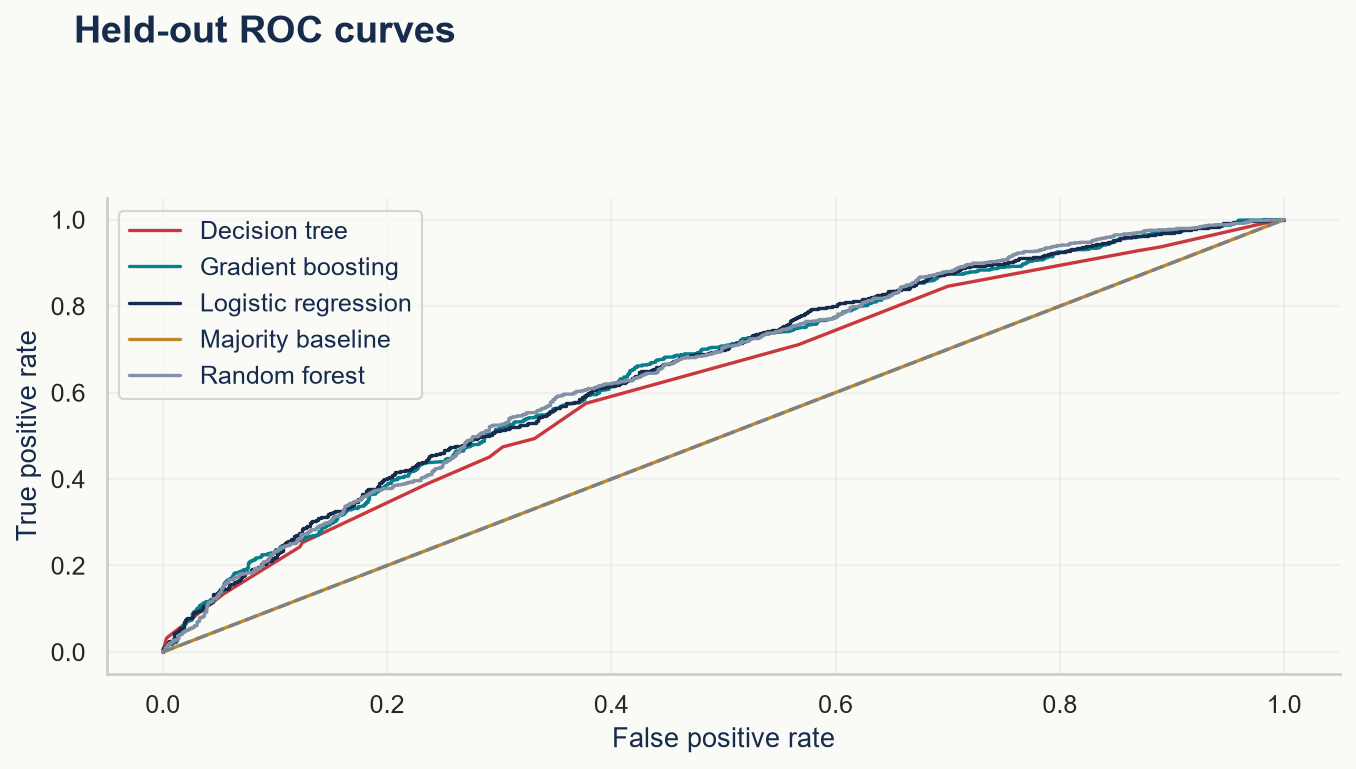

In [5]:
display(results['model_confusion'])
display(results['model_calibration'])
roc=results['roc_curves']; style()
fig,ax=plt.subplots(figsize=(9,5))
for name,rows in roc.groupby('model'):
    ax.plot(rows.false_positive_rate,rows.true_positive_rate,label=name)
ax.plot([0,1],[0,1],'--',color='gray');ax.legend()
ax.set(xlabel='False positive rate',ylabel='True positive rate')
show(finish(fig,'Held-out ROC curves'))

## Interpretation and failure modes

Logistic coefficients are standardized conditional associations. Correlated experience features complicate isolated interpretation. Report subgroup sample sizes and avoid ranking tiny groups.

In [6]:
display(results['model_coefficients'].sort_values('coefficient',key=abs,ascending=False).head(15))
display(results['model_subgroups'])

,feature,coefficient
30,categorical__weight_class_Other / unspecified,0.812966
0,numeric__age_diff,-0.318122
22,categorical__weight_class_Catch Weight,-0.315959
2,numeric__prior_wins_diff,0.241398
16,numeric__missingindicator_prior_submission_rat...,-0.197378
15,numeric__missingindicator_prior_ko_rate_diff,-0.197378
28,categorical__weight_class_Middleweight,-0.196154
17,numeric__missingindicator_prior_sig_per_minute...,0.187014
19,numeric__missingindicator_prior_td_per_15_diff,0.187014
7,numeric__prior_win_streak_diff,0.140460


,group,value,n,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss
0,weight_class,Bantamweight,208,0.629808,0.620690,0.551020,0.583784,0.684740,0.226460,0.644593
1,weight_class,Featherweight,224,0.566964,0.579439,0.543860,0.561086,0.638995,0.235827,0.663980
2,weight_class,Flyweight,143,0.594406,0.612903,0.527778,0.567164,0.649257,0.234713,0.661830
3,weight_class,Heavyweight,128,0.656250,0.671642,0.671642,0.671642,0.692195,0.225096,0.641829
4,weight_class,Light Heavyweight,128,0.562500,0.542373,0.524590,0.533333,0.602887,0.241921,0.676672
5,weight_class,Lightweight,254,0.606299,0.555556,0.575221,0.565217,0.652294,0.232076,0.656346
6,weight_class,Middleweight,227,0.616740,0.708333,0.535433,0.609865,0.684016,0.230693,0.653383
7,weight_class,Welterweight,215,0.590698,0.595745,0.528302,0.560000,0.627272,0.235610,0.663382
8,weight_class,Women's Bantamweight,72,0.611111,0.636364,0.567568,0.600000,0.649035,0.234956,0.662616
9,weight_class,Women's Flyweight,97,0.608247,0.627907,0.551020,0.586957,0.630952,0.235982,0.664690


## Limits of historical replay

The snapshot has no timestamped corrections, injury reports, odds or historical rankings. Date of birth is assumed stable; profile stance, weight, reach and career averages are excluded from modeling. Previously seen athletes can appear in later periods, so this is not an unseen-fighter evaluation. Test performance must not guide further model selection without a new holdout.

## Research extension: Which features help, when does the model fail, and how robust is its lift?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [7]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('08')
display_answers(deep_answers)

### Do richer histories help consistently before the held-out test period?

**Answer.** Across five expanding-year evaluations in 2018-2022, full historical features improve log loss in 4 of five years. Weighted log loss is 0.6730, compared with 0.6827 for age and division alone.

**Interpretation.** The same logistic specification is used for each feature family and preprocessing is refitted inside each chronological fold. Inspect year-specific results for consistency. These are exploratory development checks, not a newly untouched benchmark.

### How stable is the selected model across held-out years?

**Answer.** Annual accuracy ranges from 57.5% to 64.5% in the existing 2023-2026 holdout.

**Interpretation.** These are diagnostics of the already evaluated model, not a reason to select a different model on the same holdout. The final year has fewer months and fights.

### Are the model’s most confident predictions more reliable?

**Answer.** Accuracy rises from 51.8% in the lowest populated confidence band (n=575) to 79.5% in the highest (n=78); the highest band's mean predicted confidence is 72.1%.

**Interpretation.** Compare mean confidence with observed accuracy and interval width. No confidence cutoff is optimized on these test data; small high-confidence groups can be noisy.

### Does the model improve on always choosing the source red corner?

**Answer.** The selected model improves accuracy by 4.65 percentage points on the same fights; the paired event-bootstrap interval is 1.49 to 7.88 points.

**Interpretation.** Pairing comparisons within the same fight is more informative than comparing two separate accuracy intervals. Recurring fighters across events still create unmodeled dependence.

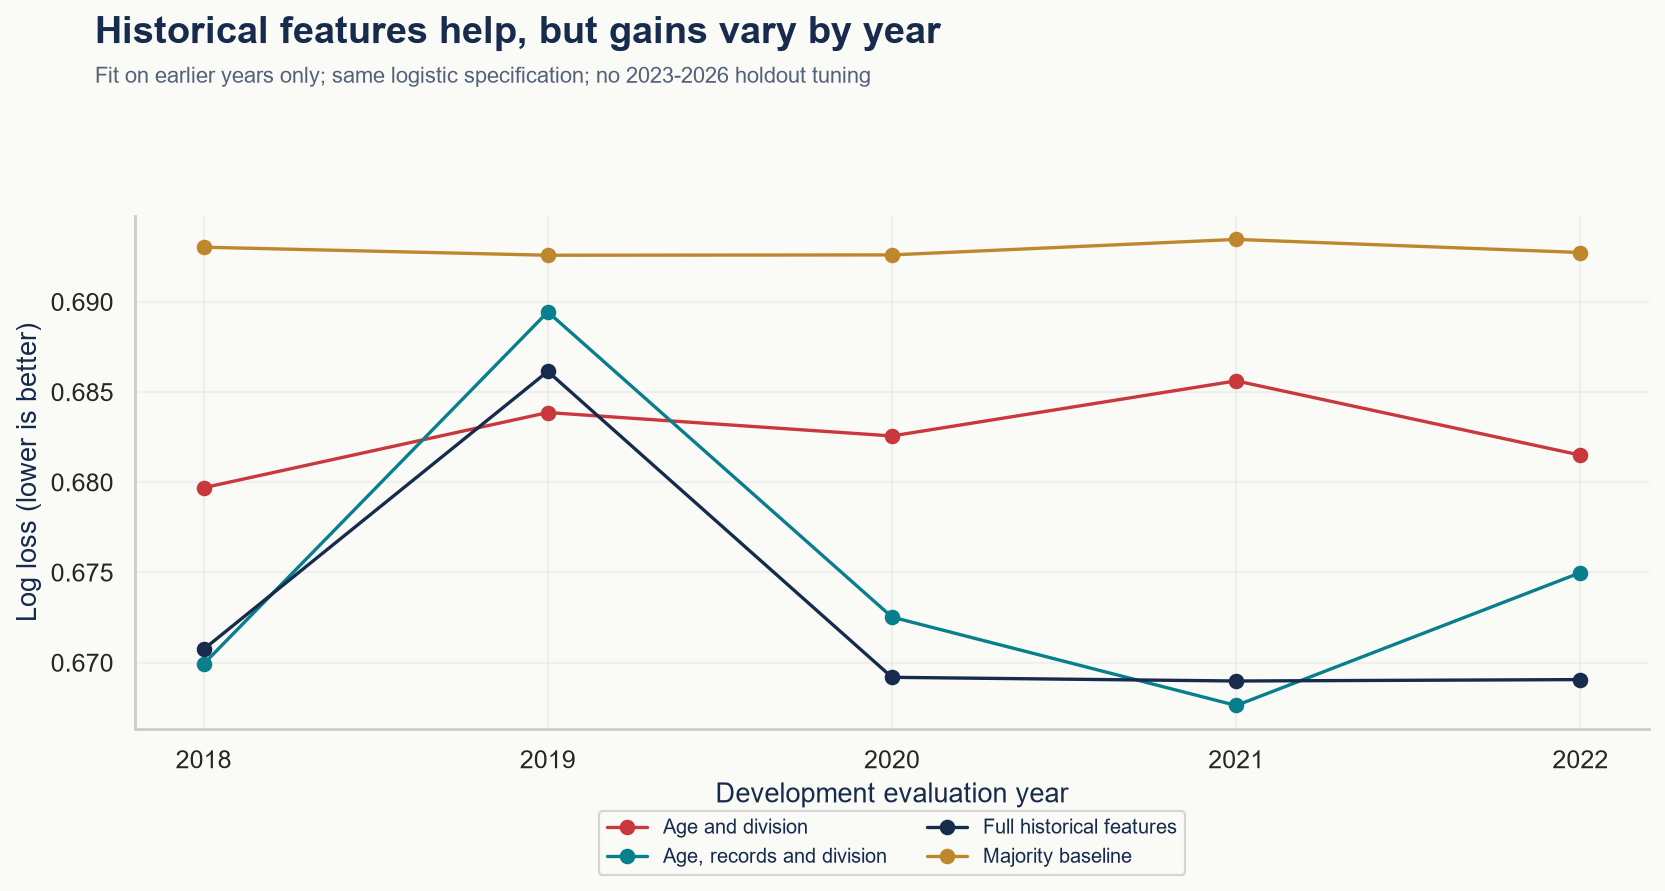

In [8]:
from src.research_visualization import research_chart
show(research_chart('08'))

In [9]:
display(deep_tables['deep_feature_ablation_summary'])

,features,validation_fights,weighted_accuracy,weighted_log_loss,weighted_mean_fold_auc
0,Age and division,2422,0.566474,0.682683,0.582199
1,"Age, records and division",2422,0.584641,0.675062,0.608833
2,Full historical features,2422,0.581751,0.672959,0.613557
3,Majority baseline,2422,0.515690,0.692882,0.500000


In [10]:
display(deep_tables['deep_feature_ablation_folds'])

,year,features,train_fights,n,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss
0,2018,Majority baseline,4391,469,0.509595,0.000000,0.000000,0.000000,0.500000,0.249939,0.693026
1,2018,Age and division,4391,469,0.571429,0.563877,0.556522,0.560175,0.586283,0.243422,0.679691
2,2018,"Age, records and division",4391,469,0.584222,0.577093,0.569565,0.573304,0.622012,0.238201,0.669923
3,2018,Full historical features,4391,469,0.569296,0.561404,0.556522,0.558952,0.619047,0.238600,0.670737
4,2019,Majority baseline,4860,506,0.533597,0.000000,0.000000,0.000000,0.500000,0.249716,0.692580
5,2019,Age and division,4860,506,0.573123,0.542735,0.538136,0.540426,0.580359,0.245320,0.683861
6,2019,"Age, records and division",4860,506,0.543478,0.510549,0.512712,0.511628,0.571218,0.247974,0.689439
7,2019,Full historical features,4860,506,0.551383,0.518519,0.533898,0.526096,0.576789,0.246503,0.686141
8,2020,Majority baseline,5366,444,0.522523,0.000000,0.000000,0.000000,0.500000,0.249725,0.692598
9,2020,Age and division,5366,444,0.576577,0.571429,0.452830,0.505263,0.596373,0.244611,0.682563


In [11]:
display(deep_tables['deep_model_years'])

,year,n,partial_year,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss
0,2023,504,False,0.593254,0.606987,0.547244,0.575569,0.626197,0.237471,0.667342
1,2024,513,False,0.575049,0.577465,0.490040,0.530172,0.633573,0.236059,0.664335
2,2025,513,False,0.615984,0.645833,0.580524,0.611440,0.672110,0.229902,0.651698
3,2026,321,True,0.644860,0.653846,0.629630,0.641509,0.690446,0.227075,0.646393


In [12]:
display(deep_tables['deep_model_confidence'])

,band,n,mean_confidence,accuracy,low,high
0,"[0.5, 0.55)",575,0.524137,0.518261,0.477434,0.558845
1,"[0.55, 0.6)",583,0.574083,0.564322,0.523782,0.604021
2,"[0.6, 0.65)",390,0.622584,0.666667,0.618456,0.711626
3,"[0.65, 0.7)",225,0.670823,0.746667,0.686025,0.799027
4,"[0.7, 0.8)",78,0.721468,0.794872,0.692460,0.869602


In [13]:
display(deep_tables['deep_paired_model_gain'])

,comparator,n,accuracy_gain,event_bootstrap_low,event_bootstrap_high
0,Majority baseline,1851,0.108050,0.076421,0.139180
1,Source red-corner heuristic,1851,0.046461,0.014939,0.078788


## Research extension: Does opponent strength improve pre-fight prediction?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [14]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('10')
display_answers(deep_answers)

### Does opponent-adjusted Elo add information beyond the existing histories?

**Answer.** Adding Elo reduces development log loss by +0.0022 (paired event-bootstrap 95% interval -0.0028 to +0.0068) and improves it in 3 of five annual evaluations.

**Interpretation.** 2018-2022 expanding-year evaluations share identical fights, preprocessing and logistic settings. Positive reduction favors adding Elo. These are already explored development data, not a new independent test; the published holdout model is unchanged.

### How informative is an Elo probability on its own?

**Answer.** The fixed K=32 Elo baseline has 55.5% accuracy, log loss 0.6860, and Brier score 0.2465 across 2,422 development evaluation fights.

**Interpretation.** Every fighter starts at 1500; scale is 400; ratings use all earlier UFC dates including 1993. Draws update with score 0.5 and no contests do not change ratings. There is no division reset, inactivity decay or professional record outside UFC.

### How sensitive are raw Elo probabilities to the update speed?

**Answer.** For K=16, 32 and 64, weighted development log loss ranges from 0.6846 to 0.6885.

**Interpretation.** All three settings are reported as a sensitivity study. K=32 is the fixed feature specification; the best observed setting is not selected on the 2023-2026 holdout. Faster updates react more strongly to recent results and can change calibration.

### Are raw Elo probabilities calibrated across their probability range?

**Answer.** Among K=32 bins with at least 50 fights, the largest observed calibration gap is 3.1 points: mean predicted 36.4%, observed 33.3% (n=54).

**Interpretation.** Fixed probability bins describe fighter A's win chance, not confidence in a predicted winner. Wilson intervals ignore recurring fighters. Binning loses detail; this diagnostic does not recalibrate probabilities on the same observations.

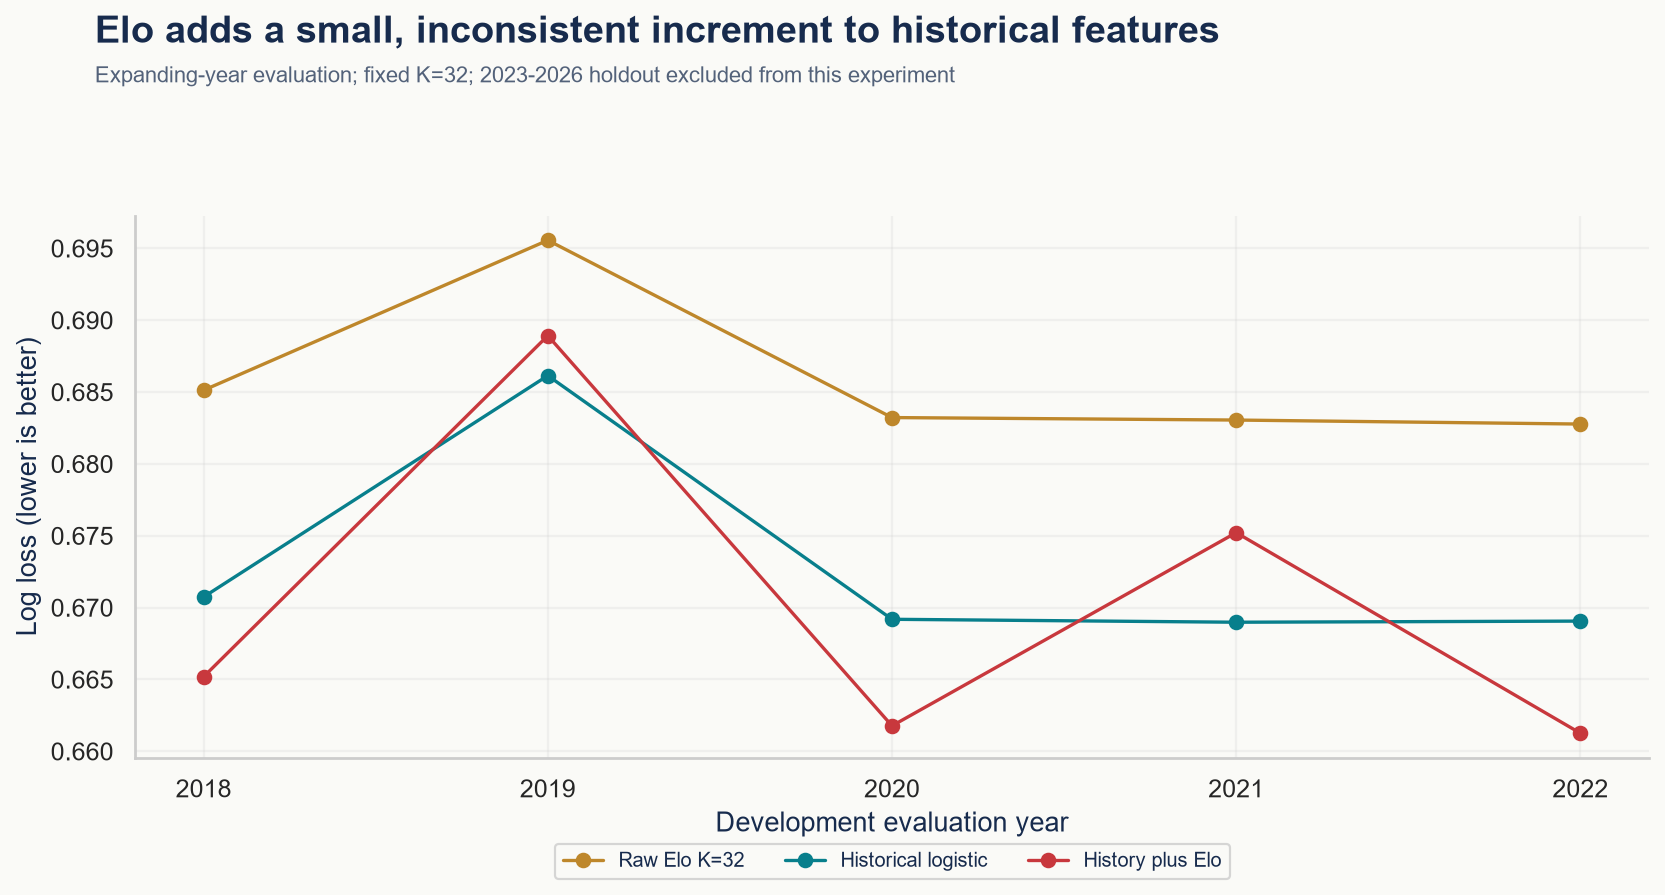

In [15]:
from src.research_visualization import research_chart
show(research_chart('10'))

In [16]:
display(deep_tables['deep_elo_summary'])

,model,n,weighted_log_loss,weighted_brier,weighted_accuracy
0,Elo and division logistic,2422,0.687522,0.247168,0.542114
1,Historical logistic,2422,0.672959,0.239884,0.581751
2,History plus Elo,2422,0.670754,0.238891,0.588357
3,Raw Elo K=16,2422,0.688530,0.247699,0.552436
4,Raw Elo K=32,2422,0.686037,0.246473,0.554913
5,Raw Elo K=64,2422,0.684568,0.245717,0.549546


In [17]:
display(deep_tables['deep_elo_folds'])

,year,model,n,train_fights,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss
0,2018,Raw Elo K=16,469,4391,0.545842,0.534979,0.565217,0.549683,0.560897,0.247401,0.687923
1,2018,Raw Elo K=32,469,4391,0.547974,0.536585,0.573913,0.554622,0.566682,0.246037,0.685124
2,2018,Raw Elo K=64,469,4391,0.545842,0.534694,0.569565,0.551579,0.574868,0.245004,0.683006
3,2018,Historical logistic,469,4391,0.569296,0.561404,0.556522,0.558952,0.619047,0.238600,0.670737
4,2018,History plus Elo,469,4391,0.579957,0.571429,0.573913,0.572668,0.631617,0.236385,0.665186
5,2018,Elo and division logistic,469,4391,0.528785,0.519824,0.513043,0.516411,0.569556,0.246098,0.685212
6,2019,Raw Elo K=16,506,4860,0.501976,0.468000,0.495763,0.481481,0.506387,0.250196,0.693533
7,2019,Raw Elo K=32,506,4860,0.505929,0.471774,0.495763,0.483471,0.506968,0.251208,0.695558
8,2019,Raw Elo K=64,506,4860,0.501976,0.468000,0.495763,0.481481,0.510813,0.254103,0.701566
9,2019,Historical logistic,506,4860,0.551383,0.518519,0.533898,0.526096,0.576789,0.246503,0.686141


In [18]:
display(deep_tables['deep_elo_gain'])

,n,log_loss_reduction,low,high
0,2422,0.002204,-0.002787,0.006846


In [19]:
display(deep_tables['deep_elo_calibration'])

,model,band,n,mean_probability,observed_win_share,low,high
0,Raw Elo K=32,"(0.2, 0.4]",54,0.364015,0.333333,0.222414,0.466390
1,Raw Elo K=32,"(0.4, 0.6]",2302,0.499962,0.484361,0.463989,0.504786
2,Raw Elo K=32,"(0.6, 0.8]",66,0.627814,0.606061,0.485484,0.714970
3,History plus Elo,"(-0.001, 0.2]",18,0.169018,0.222222,0.090009,0.452146
4,History plus Elo,"(0.2, 0.4]",555,0.339624,0.363964,0.324997,0.404801
5,History plus Elo,"(0.4, 0.6]",1429,0.495633,0.482155,0.456330,0.508076
6,History plus Elo,"(0.6, 0.8]",407,0.663540,0.665848,0.618659,0.709934
7,History plus Elo,"(0.8, 1.0]",13,0.832879,0.538462,0.291438,0.767939


## Research extension: How does the frozen model generalize across fighter familiarity?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [20]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('12')
display_answers(deep_answers)

### How often does the held-out model face fighters absent from its fitting sample?

**Answer.** 998 of 1,851 held-out fights (53.9%) include at least one fighter absent from the pre-2023 model-fitting rows.

**Interpretation.** Familiarity is fixed using IDs in the actual decisive development cohort. An athlete remains absent from the fitting sample even after earlier test appearances update their historical features. This is not the same as a UFC debut or absence from all source history.

### How does prediction quality change with the least-experienced opponent?

**Answer.** Accuracy is 58.2% when at least one fighter is a UFC debutant, versus 61.8% when both have at least five earlier UFC bouts.

**Interpretation.** Experience is measured strictly before each fight date. These are diagnostic slices of the already evaluated 2023-2026 model, with 2026 partial. No model, threshold or subgroup is selected for deployment from these results.

### Does the model improve probability quality in every reportable familiarity group?

**Answer.** The lowest reportable Brier skill is 5.5% for 'Both absent from fitting data' (n=380); all reportable groups improve over the fixed development-prevalence forecast.

**Interpretation.** Brier skill equals one minus model squared probability error divided by reference error on the same fights. A negative value is worse than that constant forecast. The reference prevalence is learned before 2023, not from each subgroup; metrics below 30 fights are withheld.

### Which familiarity group contributes the most observed model errors?

**Answer.** 'Both in fitting data' contributes 334 errors (45.5% of all held-out errors); 40 have predicted-winner confidence of at least 65%.

**Interpretation.** Error volume depends on how often a group occurs, not just its error rate. The 65% threshold is a fixed descriptive cut, not an optimized action rule. Confidence is a model probability and does not establish that a matchup was objectively predictable.

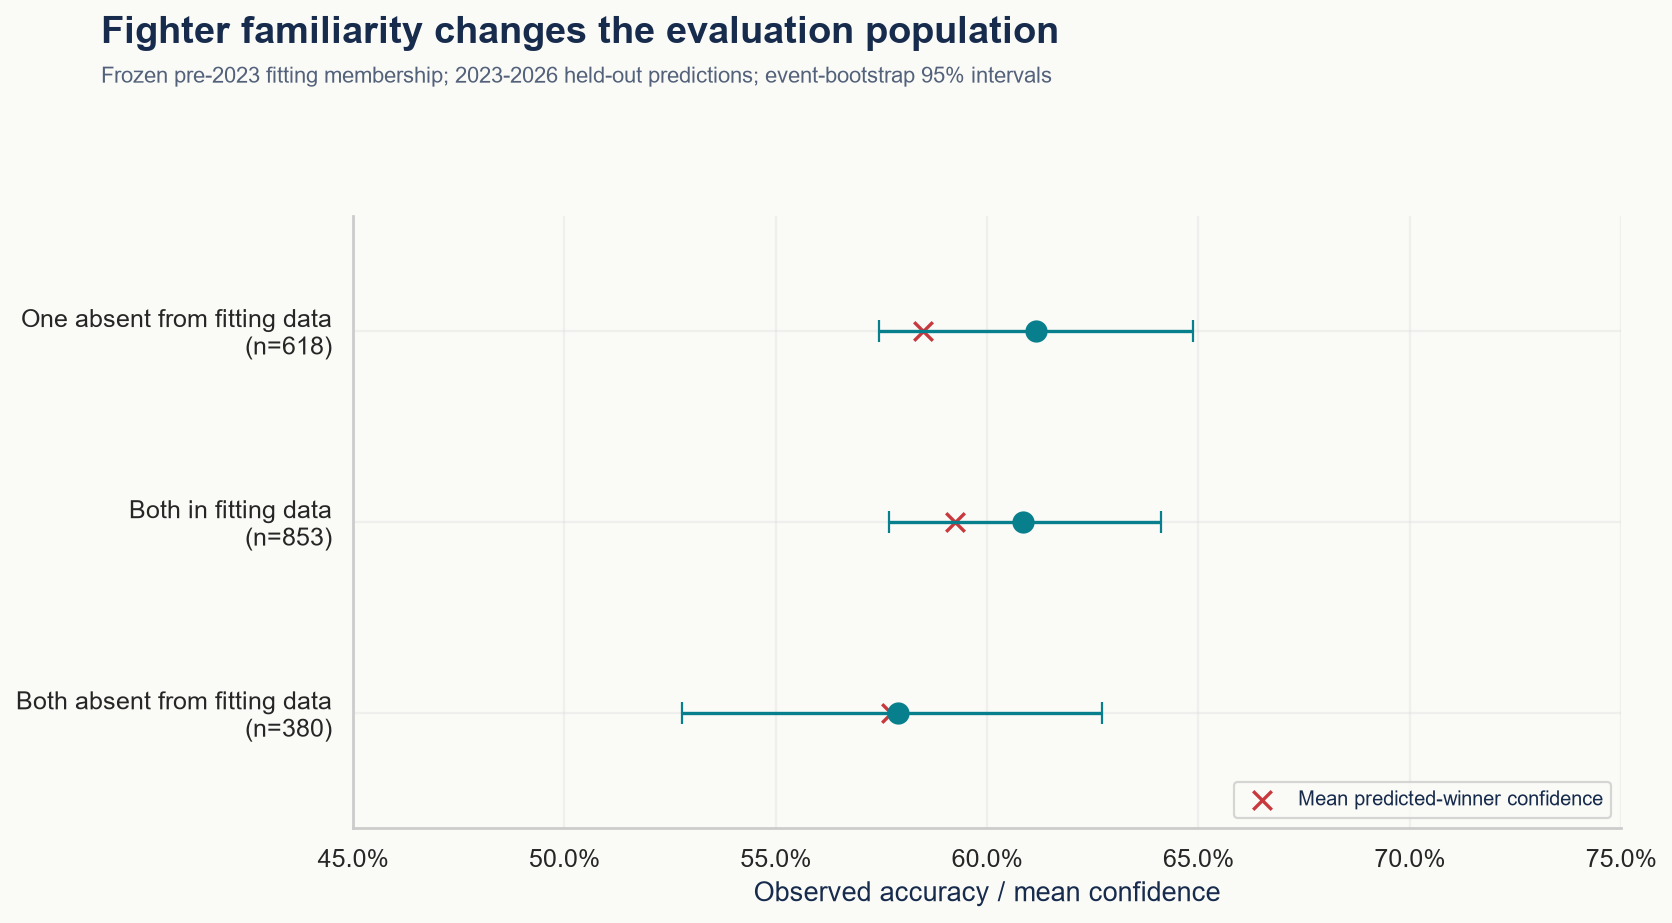

In [21]:
from src.research_visualization import research_chart
show(research_chart('12'))

In [22]:
display(deep_tables['deep_generalization_familiarity'])

,group,n,reportable,accuracy,low,high,event_low,event_high,mean_confidence,accuracy_minus_confidence,brier_score,reference_brier,brier_skill,log_loss
0,Both absent from fitting data,380,True,0.578947,0.528759,0.627556,0.527776,0.627080,0.577145,0.001802,0.237284,0.250967,0.054520,0.667151
1,Both in fitting data,853,True,0.608441,0.575269,0.640640,0.576790,0.641172,0.592391,0.016050,0.230839,0.250095,0.076995,0.653587
2,One absent from fitting data,618,True,0.611650,0.572648,0.649273,0.574318,0.648788,0.584890,0.026760,0.233885,0.249697,0.063325,0.660082


In [23]:
display(deep_tables['deep_generalization_experience'])

,group,n,reportable,accuracy,low,high,event_low,event_high,mean_confidence,accuracy_minus_confidence,brier_score,reference_brier,brier_skill,log_loss
0,At least one UFC debutant,359,True,0.582173,0.530548,0.632058,0.528302,0.634837,0.574448,0.007724,0.238127,0.249998,0.047484,0.668813
1,Both have at least 5 prior UFC bouts,735,True,0.617687,0.582030,0.652121,0.586204,0.649711,0.592125,0.025562,0.228509,0.249944,0.085762,0.648806
2,Both returning; minimum below 5,757,True,0.599736,0.564415,0.634050,0.565216,0.632772,0.587381,0.012354,0.235367,0.250400,0.060035,0.663119


In [24]:
display(deep_tables['deep_generalization_errors'])

,group,n,errors,error_share,mean_confidence_when_wrong,errors_with_confidence_at_least_65pct
0,Both absent from fitting data,380,160,0.217984,0.566299,11
1,Both in fitting data,853,334,0.455041,0.577904,40
2,One absent from fitting data,618,240,0.326975,0.575038,22
